In [2]:
import pandas as pd
from batch import BatchResult
import numpy as np
from scenarios import (
    generate_scenario_attitudes,
    MODES_2020,
)
from components.model import TechnologyAdoptionModel


In [5]:
tam = TechnologyAdoptionModel(50, province="Ontario")
for _ in range(30):
    tam.step()

Year: 2000, step: 1, el_price: 0.07211405529953917
Year: 2000.25, step: 2, el_price: 0.07211405529953917
Year: 2000.5, step: 3, el_price: 0.07211405529953917
Year: 2000.75, step: 4, el_price: 0.07211405529953917
Year: 2001.0, step: 5, el_price: 0.07735599078341013
Year: 2001.25, step: 6, el_price: 0.07735599078341013
Year: 2001.5, step: 7, el_price: 0.07735599078341013
Year: 2001.75, step: 8, el_price: 0.07735599078341013
Year: 2002.0, step: 9, el_price: 0.07488479262672812
Year: 2002.25, step: 10, el_price: 0.07488479262672812
Year: 2002.5, step: 11, el_price: 0.07488479262672812
Year: 2002.75, step: 12, el_price: 0.07488479262672812
Year: 2003.0, step: 13, el_price: 0.08117511520737328
Year: 2003.25, step: 14, el_price: 0.08117511520737328
Year: 2003.5, step: 15, el_price: 0.08117511520737328
Year: 2003.75, step: 16, el_price: 0.08117511520737328
Year: 2004.0, step: 17, el_price: 0.08641705069124425
Year: 2004.25, step: 18, el_price: 0.08641705069124425
Year: 2004.5, step: 19, el_pri

In [46]:
DEFAULT_MODES_AND_YEARS = {
    "Electric furnace": {"end_att": 0.45, "at_year": 2025},
    "Gas furnace": {"end_att": 0.45, "at_year": 2030},
    "Heat pump": {"end_att": 0.25, "at_year": 2030},
    "Oil furnace": {"end_att": 0.728319, "at_year": 2030},
    "Biomass furnace": {"end_att": 0.514116, "at_year": 2030},
}
PLUS_TRANSITION_MODES_AND_YEARS = {
    "Electric furnace": {"end_att": 0.383833, "at_year": 2030},
    "Gas furnace": {"end_att": 0.45, "at_year": 2030},
    "Heat pump": {"end_att": 0.35, "at_year": 2030},
    "Oil furnace": {"end_att": 0.728319, "at_year": 2030},
    "Biomass furnace": {"end_att": 0.514116, "at_year": 2030},
}
tech_attitude_scenario = generate_scenario_attitudes(
    MODES_2020, DEFAULT_MODES_AND_YEARS, #PLUS_TRANSITION_MODES_AND_YEARS #
)
p_mode = 0.65  # result of fit
province = "Ontario"
batch_parameters = {
    "N": [600],
    "province": [province],
    "random_seed": list(range(42, 48)),
    "n_segregation_steps": [30],
    "tech_att_mode_table": [tech_attitude_scenario],
    "price_weight_mode": [p_mode],
    "ts_step_length": ["W"],
    "start_year": 2020,
    "refurbishment_rate": 0.03,
    "hp_subsidy": 0,
    "years_per_step":1
    # "fossil_ban_year": fossil_ban_years[scen_name],
}

br = BatchResult.from_parameters(batch_parameters, max_steps=30)


results_dir=PosixPath('/home/david/src/canadopt/abetam/results/feature_utility_distribution/b44307fd5eacfff4496bd01566f524e4') does not exist. Running model.


  0%|          | 0/6 [00:00<?, ?it/s]

Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2020, step: 1, el_price: 0.10955645161290324
Year: 2021, step: 2, el_price: 0.13
Year: 2021, step: 2, el_price: 0.13
Year: 2021, step: 2, el_price: 0.13
Year: 2021, step: 2, el_price: 0.13
Year: 2021, step: 2, el_price: 0.13
Year: 2021, step: 2, el_price: 0.13
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2022, step: 3, el_price: 0.1598041474654378
Year: 2023, step: 4, el_price: 0.16006
Year: 2023, step: 4, el_price: 0.16006
Year: 2023, step: 4, el_price: 0.16006
Year: 2023, step: 4, el_price: 0.16006
Year: 2023, step: 4, e

In [47]:
def extract_df_column(df, column_name):
    dataframes = df[column_name].tolist()
    df = pd.concat(dataframes, keys=df.index)
    return df

In [48]:
br_df = br.results_df.set_index(["year", "RunId", "AgentID"])
df = br_df[["partial utilities"]].dropna()
df = extract_df_column(br_df, "partial utilities")
p_util_df_l = df.melt(ignore_index=False).reset_index().rename({"level_3": "Technology", "variable": "Partial utility"}, axis=1)
p_util_df_l.head()

,year,RunId,AgentID,Technology,Partial utility,value
0,2021,3,86,Gas furnace,economic,1.000000
1,2021,3,86,Oil furnace,economic,0.868703
2,2021,3,86,Biomass furnace,economic,0.000000
3,2021,3,86,Electric furnace,economic,0.904590
4,2021,3,86,Heat pump,economic,0.974521


In [61]:
fig = px.histogram(p_util_df_l.query("`Partial utility` == 'attitudinal' and year==2025"), x="value", color="Technology", nbins=100, template="plotly", opacity=0.5)
fig.update_layout(barmode="overlay")

In [63]:
p_util_df_l.query("`Partial utility` == 'attitudinal' and year==2025").groupby("Technology")["value"].mean()

Technology
Biomass furnace     0.601945
Electric furnace    0.427423
Gas furnace         0.681514
Heat pump           0.027387
Oil furnace         0.918233
Name: value, dtype: float64

In [49]:
# import plotly.express as px
# px.scatter(p_util_df_l, x="year", y="value", color="Technology", facet_row="variable", template="plotly")

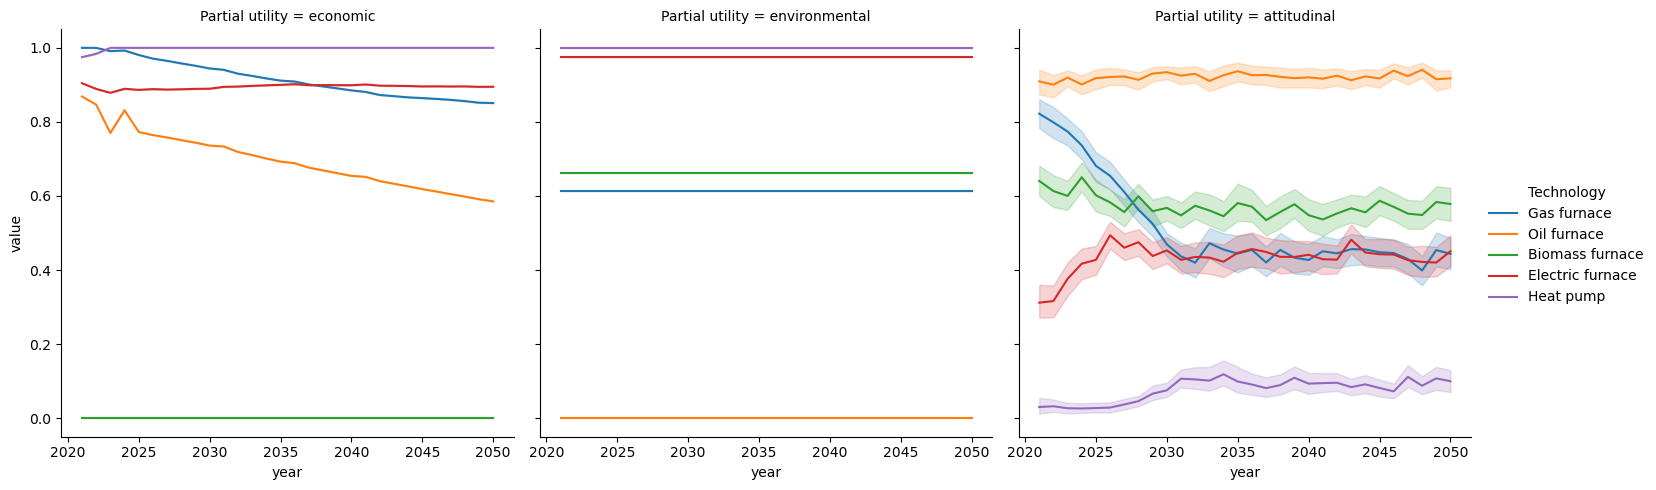

In [64]:
import seaborn as sns
g = sns.relplot(p_util_df_l, x="year", y="value", hue="Technology", col="Partial utility", kind="line", errorbar=('ci',99))

In [80]:
import plotly.express as px
from figures import sciencify_plotly_fig

tech_df = pd.read_csv("data/canada/heat_tech_params.csv", index_col=[0,1]).melt(ignore_index=False).rename({"variable":"Technology"}, axis=1)
fig = px.line(tech_df.reset_index().query("variable not in ['efficiency','lifetime', 'specific_fom_cost']"), x="year", y="value", color="Technology", facet_col="variable", template="plotly", facet_col_spacing=0.05)
fig.update_yaxes(matches=None)
fig.for_each_yaxis(lambda axis: axis.update(showticklabels=True))
fig = sciencify_plotly_fig(fig)
fig

In [ ]:
# g.figure.savefig("partial_utilities_default_modes.png")

In [30]:
# from components.model import TechnologyAdoptionModel

# tam = TechnologyAdoptionModel(100, "Ontario", n_segregation_steps=30)
# for i in range(30):
#     tam.step()

In [ ]:
# dir(tam)
df = tam.datacollector.get_agent_vars_dataframe()[["partial utilities"]].dropna()





extract_df(df)

economic  environmental  attitudinal
Step AgentID                                                       
3    89      Gas furnace       1.000000       0.704463     0.498811
             Oil furnace       0.953019       0.000000     0.000000
             Biomass furnace   0.000000       0.682828     1.000000
             Electric furnace  0.950419       0.670346     0.801332
             Heat pump         0.981521       1.000000     0.735848
...                                 ...            ...          ...
29   93      Gas furnace       0.995301       0.704463     0.616105
             Oil furnace       0.920022       0.000000     1.000000
             Biomass furnace   0.000000       0.682828     0.226682
             Electric furnace  0.933818       0.670346     0.002472
             Heat pump         1.000000       1.000000     0.000000

[360 rows x 3 columns]